# Aula 5 - Estatística Descritiva

## Motivação

Na Aula 3 você já calculou uma média: o ticket médio,
`orders["order_value"].mean()`. Funcionou, o número saiu, e você seguiu
em frente. Mas repare no que ficou por baixo do tapete: por que dividir
a soma pelo número de pedidos é a forma “certa” de resumir o valor
típico de uma venda? O que aconteceria com esse número se um único
cliente atacadista fizesse um pedido cem vezes maior que o normal? E,
alcançado esse número, ele deveria ser reportado sozinho ao gestor, ou
junto de alguma medida de o quanto os pedidos variam entre si?

Essas perguntas têm nome, e o nome é estatística descritiva: o conjunto
de ferramentas que resume uma distribuição de números em poucos valores
representativos, sem tentar generalizar além dos dados observados. É
diferente de estatística inferencial, que você verá mais adiante no
curso e que usa uma amostra para tirar conclusões sobre uma população
inteira. Hoje o objetivo é mais modesto e igualmente essencial: dado o
Online Retail que você já conhece, aprender a descrevê-lo com precisão,
medida a medida, e a escolher a medida certa para cada situação,
principalmente quando os dados não se comportam bem.

E o Online Retail não se comporta bem. Você já viu, na Aula 3, que a
base tem clientes atacadistas comprando em volumes muito acima do
padrão. Essa observação, feita ali de forma intuitiva, ganha hoje um
vocabulário preciso: assimetria, outlier, robustez. Ao final desta aula,
você vai revisitar o ticket médio da Aula 3 e conseguir dizer, com
números, se ele é ou não a melhor forma de resumir o valor de um pedido
para o gestor de vendas.

## Objetivos de aprendizagem

Ao final deste roteiro, você será capaz de:

1.  Distinguir população e amostra, e reconhecer por que a
    representatividade de uma amostra importa mais do que o seu tamanho;
2.  Calcular e interpretar as medidas de tendência central: média,
    mediana, moda e valor esperado;
3.  Calcular médias ponderada e aparada, e explicar quando cada uma é
    preferível à média simples;
4.  Calcular e interpretar as medidas de dispersão: desvio, variância,
    desvio-padrão, desvio absoluto médio, desvio absoluto mediano,
    percentis e amplitude interquartílica (IQR);
5.  Usar a assimetria (skewness) e a curtose (kurtosis) para descrever o
    formato de uma distribuição e antecipar a presença de outliers;
6.  Escolher, com justificativa, entre uma medida sensível a outliers e
    uma medida robusta, diante de uma distribuição real e assimétrica.

> **Como usar este roteiro**
>
> Este roteiro pressupõe o projeto-vendas das aulas anteriores
> funcionando, com o Online Retail já baixado em `data/`. Ele recalcula,
> na seção 2, as mesmas tabelas `sales`, `orders` e `customers`
> construídas na Aula 3, para que cada medida estatística seja aplicada
> a dados de negócio reais, não a exemplos artificiais soltos. Nenhuma
> biblioteca nova precisa ser instalada: além de pandas e numpy, o
> roteiro usa matplotlib e seaborn para os gráficos, ambas já
> disponíveis no ambiente. Ao final, três perguntas ajudam a testar se
> você sabe escolher a medida certa diante de uma distribuição real.

# 1. Retomando o projeto

Como sempre, comece verificando onde o projeto parou:

In [1]:
# Onde paramos? O git log conta a historia ate aqui:
!cd ./projeto-vendas && git log --oneline

# E o estado atual? Espera-se uma area de trabalho limpa:
!cd ./projeto-vendas && git status

bbe6150 (HEAD -> master) Adiciona pandas e registra dependencias em requirements.txt
1b4999b Adiciona .gitignore para ambiente, dados e segredos
2ce3f11 Adiciona README com a descricao do projeto
On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
    modified:   README.md
    modified:   requirements.txt

no changes added to commit (use "git add" and/or "git commit -a")

Se o log mostra os commits das aulas anteriores e o status diz que não
há nada a commitar, o ambiente e os dados estão prontos.

# 2. Preparando os dados

O ponto de partida é o mesmo da Aula 3: carregar a base, calcular a
receita por item e o sinalizador de cancelamento, e isolar as vendas
válidas.

In [2]:
import sys; print(sys.executable)

/usr/bin/python3

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = Path("projeto-vendas") / "data" / "online_retail.xlsx"

column_names = {
    "InvoiceNo": "invoice_no",
    "StockCode": "stock_code",
    "Description": "description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_date",
    "UnitPrice": "unit_price",
    "CustomerID": "customer_id",
    "Country": "country",
}

retail = pd.read_excel(data_path).rename(columns=column_names)

retail["invoice_date"] = pd.to_datetime(retail["invoice_date"], errors="coerce")
retail["revenue"] = retail["quantity"] * retail["unit_price"]
retail["is_cancelled"] = retail["invoice_no"].str.startswith("C", na=False)

valid_sales_filter = (
    ~retail["is_cancelled"]
    & retail["quantity"].gt(0)
    & retail["unit_price"].gt(0)
)

sales = retail.loc[valid_sales_filter].copy()

E as duas agregações da Aula 3 que vamos reutilizar hoje: uma linha por
pedido (`orders`) e uma linha por cliente identificado (`customers`).

In [4]:
orders = (
    sales
    .groupby("invoice_no", as_index=False)
    .agg(
        order_date=("invoice_date", "min"),
        customer_id=("customer_id", "first"),
        country=("country", "first"),
        item_quantity=("quantity", "sum"),
        order_value=("revenue", "sum"),
    )
)

customers = (
    sales
    .dropna(subset=["customer_id"])
    .groupby("customer_id", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        order_count=("invoice_no", "nunique"),
        country=("country", "first"),
    )
)

print(f"Pedidos: {len(orders):,}")
print(f"Clientes identificados: {len(customers):,}")

Pedidos: 19,960
Clientes identificados: 4,338

# 3. População e amostra

Antes de calcular qualquer medida, vale nomear sobre o que ela está
sendo calculada. Uma população é o conjunto completo que se deseja
estudar; uma amostra é um subconjunto dela, usado quando estudar a
população inteira é inviável ou caro. O Online Retail é, ele mesmo, uma
pergunta de classificação: é a população de vendas da loja, ou uma
amostra? A resposta depende do que você quer generalizar. Como um
retrato completo das transações de dezembro de 2010 a dezembro de 2011,
ele é a população daquele período. Como base para prever o comportamento
da loja no ano seguinte, ele é apenas uma amostra, um ano entre muitos
possíveis.

Essa distinção importa porque uma amostra só é útil se for
representativa, e representatividade não é a mesma coisa que tamanho. O
exemplo histórico mais citado é a eleição americana de 1936: a revista
Literary Digest enviou milhões de cartas e previu a vitória de Alf
Landon; George Gallup, com uma amostra centenas de vezes menor mas
construída para refletir o eleitorado real, previu corretamente a
vitória de Franklin D. Roosevelt. Uma amostra enorme e enviesada perde
para uma amostra pequena e representativa.

Vamos sentir isso nos nossos próprios dados. Comparamos a média de
`order_value` da população inteira de pedidos com duas amostras de 200
pedidos: uma sorteada aleatoriamente entre todos os países, e outra
enviesada, formada só por pedidos do Reino Unido, o país dominante da
base.

In [5]:
population_mean = orders["order_value"].mean()

random_sample = orders.sample(n=200, random_state=42)
random_sample_mean = random_sample["order_value"].mean()

uk_filter = orders["country"].eq("United Kingdom")
biased_sample = orders.loc[uk_filter].sample(n=200, random_state=42)
biased_sample_mean = biased_sample["order_value"].mean()

In [6]:
sampling_summary = pd.Series(
    {
        "media_populacao_completa": population_mean,
        "media_amostra_aleatoria": random_sample_mean,
        "media_amostra_enviesada_uk": biased_sample_mean,
    },
    name="order_value_medio",
)

sampling_summary.round(2).to_frame()

A amostra aleatória tende a ficar próxima da média populacional; a
amostra enviesada, não necessariamente, porque o Reino Unido tem um
padrão de compra próprio, distinto do restante do mundo. Execute a
célula de novo com outro `random_state` e observe: a amostra aleatória
oscila em torno da população, a enviesada carrega um viés sistemático
que não desaparece trocando a semente.

Os números da tabela acima já contam a história, mas fica mais fácil
enxergar o efeito do viés olhando para o formato das três distribuições
lado a lado. O gráfico a seguir sobrepõe a densidade do valor do pedido
na população completa e nas duas amostras de 200 pedidos, aleatória e
enviesada.

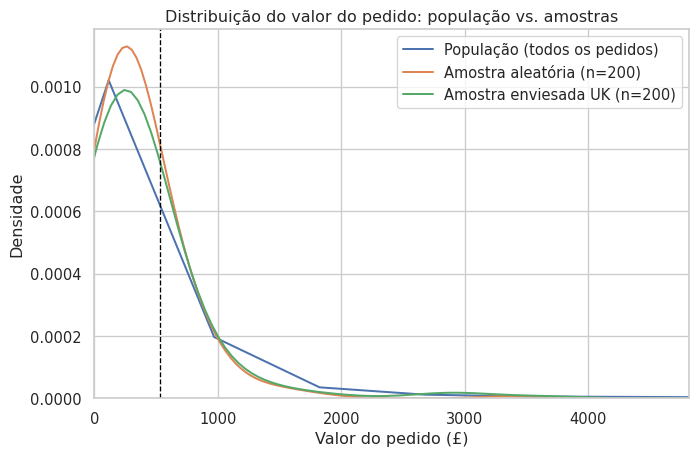

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(orders["order_value"], label="População (todos os pedidos)", ax=ax)
sns.kdeplot(random_sample["order_value"], label="Amostra aleatória (n=200)", ax=ax)
sns.kdeplot(biased_sample["order_value"], label="Amostra enviesada UK (n=200)", ax=ax)

ax.axvline(population_mean, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, orders["order_value"].quantile(0.99))
ax.set_xlabel("Valor do pedido (£)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição do valor do pedido: população vs. amostras")
ax.legend()

plt.show()

A curva da amostra aleatória acompanha de perto a curva da população:
mesmo formato, mesmo centro aproximado. Já a curva da amostra enviesada
aparece deslocada e mais estreita, concentrada numa faixa de valores
diferente — exatamente o padrão de compra do Reino Unido isolado do
resto do mundo. A linha tracejada marca a média populacional: repare que
ela cai perto do pico da amostra aleatória, mas fica deslocada em
relação ao pico da amostra enviesada, o retrato visual do viés
sistemático que a tabela numérica acima já indicava.

# 4. Medidas de tendência central

Medidas de tendência central resumem um conjunto de dados em um único
valor que representa o “centro” ou o “típico” da distribuição.

Antes de calcular qualquer medida de tendência central, vale olhar para
a forma bruta da distribuição do valor do pedido. Um histograma divide o
intervalo de valores em faixas e conta quantos pedidos caem em cada uma,
dando uma primeira impressão visual de onde os valores se concentram e
para que lado, se algum, a distribuição se estica.

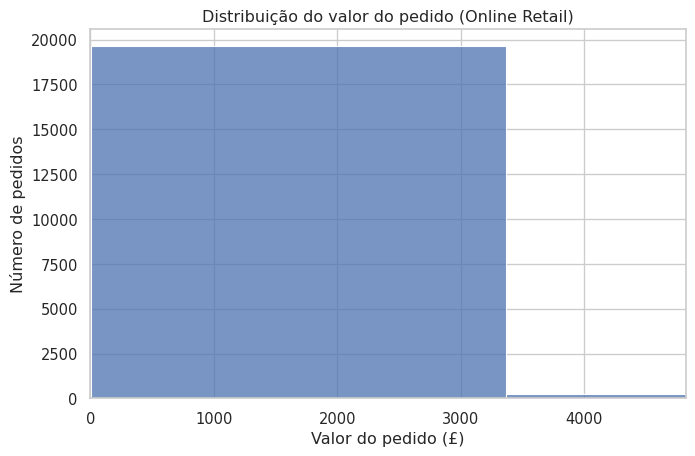

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(orders["order_value"], bins=50, ax=ax)

ax.set_xlim(0, orders["order_value"].quantile(0.99))
ax.set_xlabel("Valor do pedido (£)")
ax.set_ylabel("Número de pedidos")
ax.set_title("Distribuição do valor do pedido (Online Retail)")

plt.show()

A maior parte dos pedidos se concentra numa faixa relativamente baixa de
valores, com uma cauda que se estende para a direita: muitos pedidos
pequenos e médios, e um número bem menor de pedidos grandes. Guarde essa
forma assimétrica em mente — ela é exatamente o que vai explicar, nas
próximas seções, por que a média e a mediana do valor do pedido não
coincidem, e ela vai reaparecer, agora com números precisos de
assimetria e curtose, na seção 6.

## 4.1 Média

A média é a soma de todos os valores dividida pela quantidade de
observações. Vamos recalculá-la manualmente, para o valor dos pedidos, e
conferir que bate com o método pronto do pandas.

In [9]:
manual_mean = orders["order_value"].sum() / len(orders)
pandas_mean = orders["order_value"].mean()

print(f"Média calculada manualmente: £ {manual_mean:.2f}")
print(f"Média via .mean():           £ {pandas_mean:.2f}")

Média calculada manualmente: £ 534.40
Média via .mean():           £ 534.40

## 4.2 Valor esperado

A média tem uma segunda leitura, igualmente válida: em vez de somar
todos os valores e dividir por `n`, podemos agrupar os valores
repetidos, multiplicar cada um pela sua frequência relativa (uma
estimativa de probabilidade) e somar. Esse cálculo é o valor esperado,
`E[X] = Σ xᵢ P(X = xᵢ)`, e ele é numericamente idêntico à média quando
aplicado aos mesmos dados. Vamos confirmar isso com a quantidade de
itens por linha de venda, restrita a valores pequenos e frequentes, para
que a tabela de frequências caiba na tela.

In [10]:
small_quantities = sales.loc[sales["quantity"].between(1, 6), "quantity"]

frequency = small_quantities.value_counts().sort_index()
relative_frequency = small_quantities.value_counts(normalize=True).sort_index()

frequency_table = pd.DataFrame(
    {"frequencia": frequency, "probabilidade": relative_frequency.round(4)}
)

frequency_table

In [11]:
direct_mean = small_quantities.mean()
expected_value = (frequency_table.index.to_series() * frequency_table["probabilidade"]).sum()

print(f"Média direta:        {direct_mean:.4f}")
print(f"Valor esperado E[X]: {expected_value:.4f}")

Média direta:        2.4604
Valor esperado E[X]: 2.4604

Os dois números coincidem, e essa coincidência não é acaso: a média
amostral é o valor esperado de uma distribuição de frequências
relativas. A utilidade prática do valor esperado aparece quando ele
precisa ser comparado a um custo, para decidir se vale a pena agir — é o
mesmo cálculo que acabamos de fazer com `quantity`, só que aplicado a
uma decisão de negócio.

> **Exemplo ilustrativo: custo de aquisição por lead**
>
> O exemplo a seguir é hipotético e não usa dados do conjunto analisado
> neste material (a base de vendas `sales`/`orders`); ele serve apenas
> para mostrar, num contexto de negócio diferente, como o mesmo cálculo
> de valor esperado feito acima com `quantity` se aplica a uma decisão
> prática.
>
> Suponha que uma campanha de aquisição converta 5% dos leads em um
> plano de £ 300, 15% em um plano de £ 50 e 80% em nada. O valor
> esperado por lead é `0,05 × 300 + 0,15 × 50 + 0,80 × 0 = £ 22,50`.
> Qualquer custo de aquisição por lead abaixo desse valor tende a gerar
> retorno positivo; acima dele, tende a destruir valor.

> **O que é um “lead”?**
>
> Lead é o termo de marketing e vendas para um contato que demonstrou
> algum interesse em um produto, mas ainda não comprou nada — por
> exemplo, ao preencher um formulário, pedir um orçamento ou se
> inscrever numa lista de espera. É a etapa anterior à de cliente: cada
> lead carrega uma certa probabilidade de se converter (virar cliente
> pagante) ou de nunca converter, e um funil de vendas típico gera muito
> mais leads do que conversões. No exemplo acima, os 5%, 15% e 80% são
> justamente essas probabilidades de conversão, tratando o conjunto de
> leads como a “distribuição de frequências relativas” sobre a qual o
> valor esperado é calculado.
>
> Esse valor esperado não é uma constante da campanha: ele depende
> diretamente das taxas de conversão, que variam com a qualidade do lead
> (um contato mais qualificado converte mais) e com a execução da
> campanha (uma segmentação ruim ou uma oferta mal direcionada reduz a
> conversão). Se a conversão cair — por exemplo, de 5% para 3% no plano
> de £ 300, com o restante redistribuído para “nada” —, o valor esperado
> por lead cai junto: `0,03 × 300 + 0,15 × 50 + 0,82 × 0 = £ 16,50`.
> Como o teto de custo de aquisição aceitável é justamente esse valor
> esperado, uma queda na conversão reduz quanto a empresa pode pagar por
> lead sem destruir valor: um custo de aquisição de £ 20, lucrativo
> quando a conversão era 5% (limite de £ 22,50), passa a gerar prejuízo
> quando ela cai para 3% (novo limite de £ 16,50). Por isso, acompanhar
> a taxa de conversão é tão importante quanto acompanhar o custo por
> lead — os dois lados dessa desigualdade precisam ser reavaliados
> juntos, e não isoladamente.

## 4.3 Média ponderada e média aparada

A média simples trata cada linha da base como igualmente importante, mas
nem toda pergunta é sobre linhas: às vezes é sobre unidades vendidas.
Compare a média simples do preço unitário com a média ponderada pela
quantidade vendida de cada item, que é o preço médio efetivamente pago
por unidade.

In [12]:
simple_price_mean = sales["unit_price"].mean()
weighted_price_mean = (sales["unit_price"] * sales["quantity"]).sum() / sales["quantity"].sum()

print(f"Preço médio simples (por linha):        £ {simple_price_mean:.2f}")
print(f"Preço médio ponderado (por unidade):    £ {weighted_price_mean:.2f}")

Preço médio simples (por linha):        £ 3.91
Preço médio ponderado (por unidade):    £ 1.91

As duas médias divergem porque itens baratos costumam ser vendidos em
quantidades maiores nesta base. A média simples dá o mesmo peso a uma
linha de 1 unidade e a uma linha de 5.000 unidades; a ponderada reflete
o que de fato aconteceu em volume.

Outra forma de controlar a influência de valores extremos é aparar as
pontas antes de calcular a média: descartar uma proporção dos menores e
dos maiores valores. O pandas não tem uma função pronta para isso, então
escrevemos uma:

In [13]:
def trimmed_mean(series, proportion=0.05):
    ordered = series.sort_values().reset_index(drop=True)
    cut = int(len(ordered) * proportion)
    return ordered.iloc[cut: len(ordered) - cut].mean()

order_value_trimmed = trimmed_mean(orders["order_value"], proportion=0.05)

print(f"Média simples do valor do pedido: £ {orders['order_value'].mean():.2f}")
print(f"Média aparada (5% de cada lado):  £ {order_value_trimmed:.2f}")

Média simples do valor do pedido: £ 534.40
Média aparada (5% de cada lado):  £ 366.44

A média aparada cai bem abaixo da média simples: um punhado de pedidos
muito grandes, no topo da distribuição, puxa a média simples para cima,
e removê-los revela um centro mais modesto. Guarde esse resultado; ele
vai reaparecer na seção 5.

## 4.4 Mediana

A mediana é o valor central de um conjunto ordenado: metade das
observações fica abaixo dela, metade acima. Diferentemente da média, ela
não soma valor nenhum, só observa a posição, o que a torna insensível à
magnitude dos extremos.

In [14]:
order_value_median = orders["order_value"].median()

print(f"Média do valor do pedido:   £ {orders['order_value'].mean():.2f}")
print(f"Mediana do valor do pedido: £ {order_value_median:.2f}")

Média do valor do pedido:   £ 534.40
Mediana do valor do pedido: £ 303.84

## 4.5 Moda

A moda é o valor (ou categoria) mais frequente. Ela pode ser calculada
tanto para variáveis numéricas quanto categóricas, e nem sempre é única.

In [15]:
quantity_mode = sales["quantity"].mode()
country_mode = sales["country"].mode()

print(f"Quantidade mais frequente por linha de venda: {quantity_mode.tolist()}")
print(f"País mais frequente: {country_mode.tolist()}")

Quantidade mais frequente por linha de venda: [1]
País mais frequente: ['United Kingdom']

O exemplo acima, com `quantity` e `country`, tem uma moda única e bem
definida. Mas “nem sempre é única” significa mais do que empates: quando
uma distribuição mistura dois grupos com padrões de compra bem
diferentes, o histograma pode mostrar dois picos distintos — uma
distribuição bimodal —, sinal visual de que talvez valha separar os dois
grupos antes de resumir qualquer medida.

> **Exemplo ilustrativo: distribuição bimodal de clientes varejo e
> atacado**
>
> O exemplo a seguir é hipotético e não usa dados do conjunto analisado
> neste material (a base de vendas `sales`/`orders`); ele serve apenas
> para mostrar, com dados sintéticos, como é a forma de uma distribuição
> com mais de uma moda, algo que não aparece naturalmente no valor do
> pedido do Online Retail.
>
> Suponha uma loja hipotética com dois grupos de clientes bem distintos:
> um grupo de varejo, que compra pouco e com frequência, e um grupo de
> atacado, que compra muito e raramente. Gerando valores de pedido
> sintéticos para os dois grupos e combinando-os numa única
> distribuição, o histograma abaixo aparece com dois picos claramente
> separados, um para cada grupo.

In [16]:
rng = np.random.default_rng(42)

varejo = rng.normal(loc=50, scale=15, size=800)
atacado = rng.normal(loc=300, scale=40, size=200)

illustrative_orders = np.concatenate([varejo, atacado])
illustrative_orders = illustrative_orders[illustrative_orders > 0]

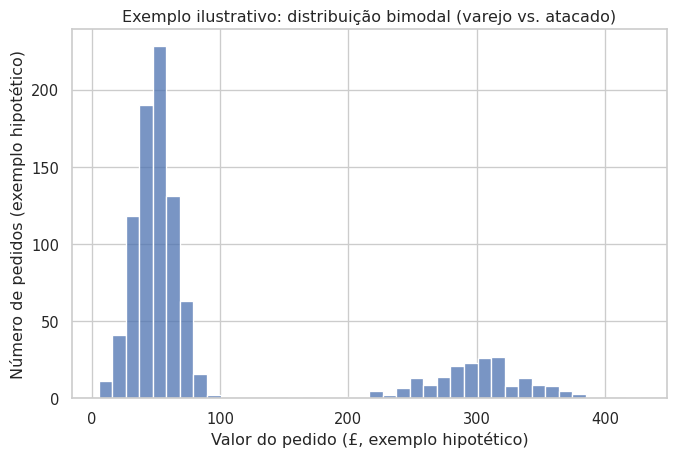

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(illustrative_orders, bins=40, ax=ax)

ax.set_xlabel("Valor do pedido (£, exemplo hipotético)")
ax.set_ylabel("Número de pedidos (exemplo hipotético)")
ax.set_title("Exemplo ilustrativo: distribuição bimodal (varejo vs. atacado)")

plt.show()

Note os dois picos separados: um em torno de £ 50, o grupo varejo, outro
em torno de £ 300, o grupo atacado. Calcular a moda, a média ou a
mediana dessa distribuição combinada sem saber da existência dos dois
grupos produziria um número que não representa bem nenhum dos dois. É
uma pista de que, diante de um histograma com mais de um pico, a
pergunta certa muitas vezes não é “qual é a medida certa para resumir
isso”, e sim “esses dados deveriam ser dois grupos separados antes de
resumir”.

## 4.6 Média versus mediana: o problema do cliente atacadista

Em 2016 circulou um exemplo que ilustra bem o risco da média: formandos
em Geografia de uma universidade americana pareciam ter um salário
inicial médio surpreendentemente alto, até se descobrir que um único
ex-aluno, Michael Jordan, elevava sozinho a média de todo o grupo. Sem
ele, o salário típico da turma era bem mais modesto. Isso é assimetria
em ação: um único valor extremo distorce a média sem distorcer a
mediana.

O nosso Online Retail tem o próprio Michael Jordan, na verdade vários:
os clientes atacadistas identificados na Aula 3. Vamos comparar a
receita média por cliente com e sem o cliente de maior receita da base.

In [18]:
top_customer = customers.nlargest(1, "revenue")
top_customer_id = top_customer["customer_id"].iloc[0]
top_customer_revenue = top_customer["revenue"].iloc[0]

customers_without_top = customers.loc[customers["customer_id"].ne(top_customer_id)]

comparison = pd.Series(
    {
        "media_com_todos_os_clientes": customers["revenue"].mean(),
        "media_sem_o_maior_cliente": customers_without_top["revenue"].mean(),
        "mediana_com_todos_os_clientes": customers["revenue"].median(),
        "mediana_sem_o_maior_cliente": customers_without_top["revenue"].median(),
    },
    name="receita_por_cliente",
)

print(f"Maior cliente (ID {top_customer_id}): £ {top_customer_revenue:,.2f}")
comparison.round(2).to_frame()

Maior cliente (ID 14646.0): £ 280,206.02

Remover um único cliente muda a média visivelmente; a mediana quase não
se mexe. Esse é o teste prático para decidir qual medida reportar: se
tirar a maior observação muda muito o resultado, a média está sendo
carregada por poucos pontos, e a mediana é o resumo mais honesto do
“cliente típico”.

# 5. Medidas de dispersão

Duas distribuições podem ter a mesma média e ainda assim se comportar de
formas muito diferentes: uma compacta em torno do centro, outra
espalhada. As medidas de dispersão capturam essa diferença.

## 5.1 Desvio, variância e desvio-padrão

O desvio de uma observação é a distância entre ela e a média: `xᵢ - x̄`.
A variância é a média dos desvios elevados ao quadrado (o quadrado evita
que desvios positivos e negativos se cancelem), e o desvio-padrão é a
raiz quadrada da variância, o que o traz de volta para a escala original
dos dados.

In [19]:
order_values = orders["order_value"]

deviations = order_values - order_values.mean()
manual_variance = (deviations ** 2).mean()
manual_std = np.sqrt(manual_variance)

pandas_variance = order_values.var(ddof=0)
pandas_std = order_values.std(ddof=0)

print(f"Variância manual:  {manual_variance:,.2f}")
print(f"Variância pandas:  {pandas_variance:,.2f}")
print(f"Desvio-padrão manual: {manual_std:,.2f}")
print(f"Desvio-padrão pandas: {pandas_std:,.2f}")

Variância manual:  3,169,977.44
Variância pandas:  3,169,977.44
Desvio-padrão manual: 1,780.44
Desvio-padrão pandas: 1,780.44

Na prática, com milhares de pedidos, a diferença entre dividir por `n`
ou por `n - 1` é desprezível; o hábito de usar `ddof=1` (o padrão)
importa mais quando a amostra é pequena.

## 5.2 Desvio absoluto médio e desvio absoluto mediano

A variância penaliza desvios grandes desproporcionalmente, por causa do
quadrado, o que a torna sensível a outliers. Duas alternativas mais
robustas trabalham com valores absolutos em vez de quadrados: o desvio
absoluto médio, em relação à média, e o desvio absoluto mediano (MAD),
em relação à mediana, a mais resistente das duas a valores extremos.

In [20]:
mean_absolute_deviation = (order_values - order_values.mean()).abs().mean()
median_absolute_deviation = (order_values - order_values.median()).abs().median()

dispersion_comparison = pd.Series(
    {
        "desvio_padrao": order_values.std(ddof=0),
        "desvio_absoluto_medio": mean_absolute_deviation,
        "desvio_absoluto_mediano": median_absolute_deviation,
    },
    name="valor_em_libras",
)

dispersion_comparison.round(2).to_frame()

O desvio-padrão sai bem maior que as duas alternativas robustas, sinal
de que poucos pedidos muito distantes do centro estão inflando a
variância desproporcionalmente. Isso é consistente com o que já vimos na
seção 4: a distribuição do valor dos pedidos não é bem comportada.

## 5.3 Percentis e amplitude interquartílica

Um percentil `P` é o valor abaixo do qual cai uma determinada
porcentagem das observações. Os quartis são os percentis 25, 50 (a
mediana) e 75, e a amplitude interquartílica (IQR) é a distância entre o
terceiro e o primeiro quartil: o espalhamento da metade central dos
dados, imune ao que acontece nas pontas.

In [21]:
q1 = order_values.quantile(0.25)
q2 = order_values.quantile(0.50)
q3 = order_values.quantile(0.75)
iqr = q3 - q1

quartile_summary = pd.Series(
    {"Q1 (25%)": q1, "Q2 (mediana, 50%)": q2, "Q3 (75%)": q3, "IQR": iqr},
    name="order_value",
)

quartile_summary.round(2).to_frame()

Uma regra prática, amplamente usada, marca como potencial outlier
qualquer observação além de `1,5 × IQR` para além do Q1 ou do Q3. Vamos
aplicá-la e, antes de descartar qualquer coisa, investigar quem são os
pedidos sinalizados, exatamente como a Aula 3 recomendou ao discutir
atacado versus erro.

In [22]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_filter = order_values.lt(lower_bound) | order_values.gt(upper_bound)
flagged_orders = orders.loc[outlier_filter]

print(f"Limite inferior: £ {lower_bound:,.2f}")
print(f"Limite superior: £ {upper_bound:,.2f}")
print(f"Pedidos sinalizados pela regra do IQR: {len(flagged_orders):,} de {len(orders):,}")

Limite inferior: £ -362.15
Limite superior: £ 1,010.27
Pedidos sinalizados pela regra do IQR: 1,811 de 19,960

In [23]:
flagged_orders["country"].value_counts().head(10)

country
United Kingdom    1464
EIRE                68
Germany             47
France              44
Netherlands         43
Spain               20
Switzerland         12
Australia           11
Norway              11
Japan               11
Name: count, dtype: int64

Os pedidos sinalizados se concentram fortemente em poucos países, o
mesmo padrão de compra em grande volume por clientes específicos que a
Aula 3 já havia levantado como hipótese de atacado, e não de erro. A
regra do IQR é útil para localizar candidatos a outlier; decidir se cada
um é erro ou atacado legítimo continua sendo trabalho de investigação,
não de fórmula.

Os números calculados acima — quartis, IQR e os limites de 1,5 × IQR —
têm uma representação visual padrão: o boxplot. Ele desenha a caixa
entre Q1 e Q3 (os 50% centrais dos dados), uma linha na mediana, bigodes
até o último valor dentro do limite de 1,5 × IQR, e marca
individualmente qualquer ponto além disso — exatamente os mesmos pedidos
que acabamos de isolar em `flagged_orders`.

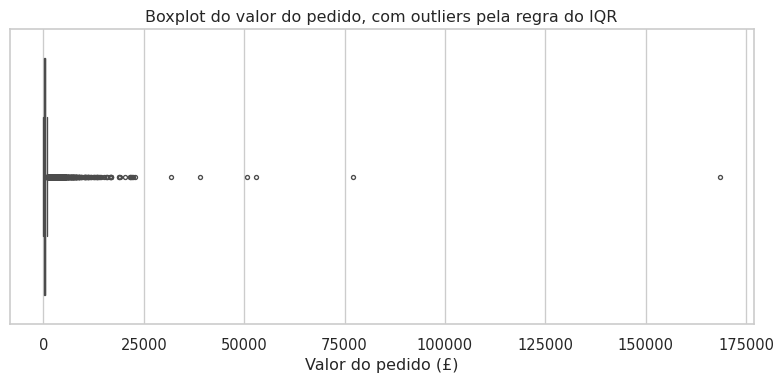

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x=order_values, ax=ax, whis=1.5, fliersize=3)

ax.set_xlabel("Valor do pedido (£)")
ax.set_title("Boxplot do valor do pedido, com outliers pela regra do IQR")

plt.show()

A caixa central, compacta, mostra onde está a maioria dos pedidos; a
fileira de pontos à direita é a cauda de pedidos de atacado que a regra
do IQR sinalizou. É a mesma conclusão da tabela `flagged_orders` acima,
agora numa forma que deixa imediatamente claro o quão longe esses
pedidos estão do restante da distribuição.

# 6. Assimetria e curtose

Assimetria (skewness) e curtose (kurtosis) descrevem o formato de uma
distribuição além do centro e do espalhamento: a primeira mede para que
lado a cauda se estica, a segunda mede o quão pesadas são as caudas, ou
seja, a propensão a valores extremos. As duas são calculadas em relação
à distribuição normal, para a qual assimetria e excesso de curtose valem
zero.

In [25]:
order_value_skew = order_values.skew()
order_value_kurtosis = order_values.kurt()

print(f"Assimetria (skewness) do valor do pedido: {order_value_skew:.2f}")
print(f"Excesso de curtose (kurtosis) do valor do pedido: {order_value_kurtosis:.2f}")

Assimetria (skewness) do valor do pedido: 51.07
Excesso de curtose (kurtosis) do valor do pedido: 4235.78

Assimetria positiva e alta: a cauda longa está à direita, moda menor que
mediana, que é menor que a média, exatamente a relação que explicou por
que a média do valor do pedido ficou acima da mediana na seção 4.
Curtose positiva e alta: caudas muito mais pesadas que as de uma normal,
ou seja, valores extremamente distantes do centro (os pedidos de
atacado) aparecem com frequência bem maior do que uma distribuição
normal preveria. Os dois números, juntos, são a versão quantitativa
exata da suspeita que tivemos olhando o `describe()` desde a Aula 2.

Os números de assimetria e curtose acima descrevem um formato que fica
muito mais fácil de reconhecer olhando para o histograma do valor do
pedido, desta vez com a média, a mediana e a moda marcadas.

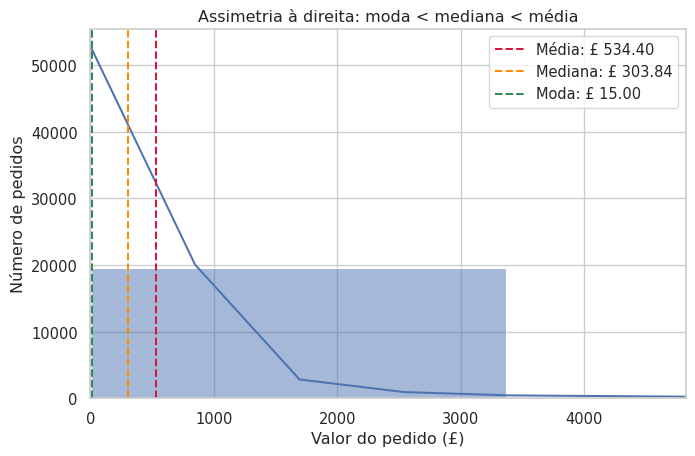

In [26]:
order_value_mean = order_values.mean()
order_value_median = order_values.median()
order_value_mode = order_values.mode().iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(order_values, bins=50, kde=True, ax=ax)

ax.axvline(order_value_mean, color="crimson", linestyle="--", label=f"Média: £ {order_value_mean:,.2f}")
ax.axvline(order_value_median, color="darkorange", linestyle="--", label=f"Mediana: £ {order_value_median:,.2f}")
ax.axvline(order_value_mode, color="seagreen", linestyle="--", label=f"Moda: £ {order_value_mode:,.2f}")

ax.set_xlim(0, order_values.quantile(0.99))
ax.set_xlabel("Valor do pedido (£)")
ax.set_ylabel("Número de pedidos")
ax.set_title("Assimetria à direita: moda < mediana < média")
ax.legend()

plt.show()

As três linhas verticais aparecem na ordem que a assimetria positiva
prevê: moda à esquerda, mediana no meio, média mais à direita, puxada
pela cauda longa de pedidos grandes — a mesma cauda que a curtose alta
identifica como mais pesada do que uma distribuição normal teria. É o
mesmo padrão discutido em números na seção 4.6, agora visível numa única
imagem.

A assimetria já ficou visível comparando moda, mediana e média no
histograma acima. A curtose é mais sutil de enxergar diretamente nos
dados reais, porque ela descreve o peso das caudas, não a posição do
pico.

> **Exemplo ilustrativo: o que curtose alta parece, visualmente**
>
> O exemplo a seguir é hipotético e não usa dados do conjunto analisado
> neste material (a base de vendas `sales`/`orders`); ele serve apenas
> para isolar visualmente o efeito da curtose, comparando duas
> distribuições sintéticas com o mesmo centro e a mesma escala
> aproximada, mas caudas de pesos diferentes.

O par de histogramas sintéticos abaixo isola esse efeito: duas
distribuições centradas no mesmo lugar, uma com curtose próxima de zero,
outra com curtose alta.

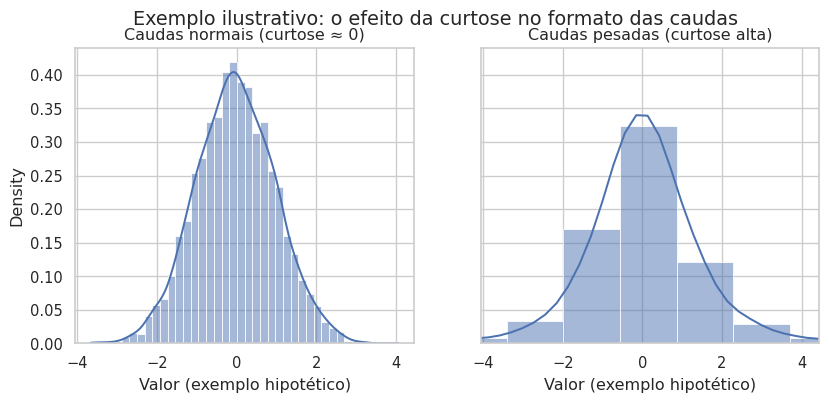

In [27]:
rng = np.random.default_rng(7)

normal_tail = rng.normal(loc=0, scale=1, size=5000)
heavy_tail = rng.standard_t(df=3, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.histplot(normal_tail, bins=40, ax=axes[0], stat="density", kde=True)
axes[0].set_title("Caudas normais (curtose ≈ 0)")
axes[0].set_xlabel("Valor (exemplo hipotético)")

sns.histplot(heavy_tail, bins=40, ax=axes[1], stat="density", kde=True)
axes[1].set_title("Caudas pesadas (curtose alta)")
axes[1].set_xlabel("Valor (exemplo hipotético)")
axes[1].set_xlim(axes[0].get_xlim())

fig.suptitle("Exemplo ilustrativo: o efeito da curtose no formato das caudas")

plt.show()

As duas distribuições têm o mesmo centro e um formato parecido perto do
pico, mas a da direita tem valores extremos, longe do centro, com
frequência bem maior. É visualmente isso que a curtose alta do valor do
pedido, medida acima, está descrevendo: pedidos muito distantes do
centro aparecem com frequência maior do que uma normal preveria.

Recapitulando o que este roteiro entrega:

-   Distinguiu população e amostra, e visualizou, sobrepondo as
    distribuições, como uma amostra enviesada se desloca em relação à
    população enquanto uma amostra aleatória a acompanha;
-   Calculou média, valor esperado, média ponderada e média aparada,
    mostrando que todas descrevem “o centro”, mas reagem de formas
    diferentes a valores extremos;
-   Comparou média e mediana do valor do pedido e da receita por
    cliente, isolando o efeito dos clientes atacadistas sobre cada
    medida;
-   Calculou variância, desvio-padrão e suas alternativas robustas
    (desvio absoluto médio e mediano), evidenciando a sensibilidade da
    variância a outliers;
-   Usou percentis, a amplitude interquartílica e um boxplot para
    sinalizar e visualizar pedidos extremos, sem descartá-los sem
    investigação;
-   Quantificou, com assimetria e curtose, o formato da distribuição do
    valor dos pedidos, e viu esse formato de forma visual pela primeira
    vez nesta aula, confirmando com precisão numérica o que a inspeção
    do `describe()` já sugeria desde a Aula 2.

# Perguntas para consolidar

Três perguntas para testar se você sabe escolher a medida certa diante
de uma distribuição real, não apenas calculá-la. Elas não têm uma
resposta única certa: o que importa é a justificativa.

## Pergunta 1: qual “ticket médio” você reportaria ao gestor?

A Aula 3 calculou o ticket médio como a média simples do valor dos
pedidos. Depois de ver, nesta aula, a diferença entre média, mediana e
média aparada para essa mesma variável, e depois de medir sua assimetria
e curtose, você manteria a média simples como o número a reportar ao
gestor de vendas, ou trocaria por outra medida? E reportaria ela
sozinha, ou acompanhada de alguma medida de dispersão?

> **Como pensar sobre isso**
>
> Não existe medida “errada” em absoluto, existe medida mal escolhida
> para a pergunta. Se o gestor quer saber o valor típico de um pedido,
> para dimensionar operação ou estoque, a mediana (ou a média aparada) é
> mais honesta, porque a média simples está sendo puxada para cima pelos
> pedidos de atacado, como você mediu diretamente na seção 4.6. Se o
> gestor quer o faturamento total esperado por pedido, para projeção
> financeira, a média simples é exatamente a medida certa, porque ela
> preserva a soma total quando multiplicada pelo número de pedidos, e a
> mediana não tem essa propriedade. A resposta, portanto, depende da
> pergunta de negócio por trás do número, não de uma regra fixa. Em
> qualquer um dos dois casos, reportar a média ou a mediana sozinha, sem
> uma medida de dispersão (o desvio-padrão, o IQR, ou ao menos os
> quartis), esconde justamente a informação que esta aula tornou
> visível: o quanto os pedidos variam entre si.

## Pergunta 2: a regra do IQR é suficiente para decidir o que é outlier?

Na seção 5.3, a regra de `1,5 × IQR` sinalizou um conjunto de pedidos
extremos, concentrados em poucos países. Isso é evidência suficiente
para excluí-los de uma análise de faturamento por serem outliers?

> **Como pensar sobre isso**
>
> Não sozinha. A regra do IQR é uma ferramenta de triagem estatística:
> ela aponta candidatos a valor atípico com base apenas na posição do
> valor na distribuição, sem saber nada sobre o que aquele valor
> significa no negócio. A Aula 3 já havia levantado a hipótese de que
> volumes muito altos, concentrados em poucos clientes e países, são
> padrão de compra atacadista legítimo, não erro de digitação. Cruzar os
> pedidos sinalizados pelo IQR com `customer_id` e `country`, como
> fizemos na seção 5.3, é o passo que falta entre “a estatística aponta
> um candidato” e “a decisão de negócio confirma o que ele é”. Descartar
> por fórmula, sem esse cruzamento, corre o risco de apagar justamente
> os clientes mais valiosos da base.

## Pergunta 3: o ano do Online Retail é população ou amostra?

Releia a seção 3. Se a loja perguntasse “o ticket médio do próximo ano
será parecido com o que calculamos aqui?”, sua resposta mudaria
dependendo de tratar este ano de dados como população ou como amostra? O
que precisaria ser verdade sobre o próximo ano para que as medidas
calculadas nesta aula continuassem valendo?

> **Como pensar sobre isso**
>
> Como retrato de dezembro de 2010 a dezembro de 2011, esses dados são a
> população completa daquele período: toda medida calculada sobre eles é
> exata para aquele ano, sem erro de amostragem. Como base para prever o
> ano seguinte, porém, eles viram uma amostra de tamanho um, um único
> ano observado entre muitos anos possíveis, e usá-los para prever o
> futuro exige assumir que o padrão de vendas se mantém razoavelmente
> estável: mesma mistura de clientes, mesma sazonalidade, sem eventos
> extraordinários. Essa suposição pode ser razoável ou perigosa,
> dependendo do negócio, e é exatamente o tipo de julgamento que separa
> aplicar uma fórmula de interpretar um resultado. A estatística
> descritiva descreve o passado com precisão; generalizar esse passado
> para o futuro é inferência, e vem com incerteza que nenhuma das
> medidas desta aula quantifica sozinha.

# Para casa

1.  Repita as seções 4 e 5 para a variável `unit_price` (em vez de
    `order_value`), calculando média, mediana, média aparada,
    desvio-padrão, desvio absoluto mediano, assimetria e curtose. O
    preço unitário é tão assimétrico quanto o valor do pedido?
2.  Escreva, em uma célula de texto, um parágrafo dirigido ao gestor de
    vendas explicando, sem jargão estatístico, por que a mediana do
    valor do pedido é diferente da média, e qual das duas ele deveria
    usar para tomar decisões operacionais.
3.  Usando a mesma lógica da seção 4.6 (comparar a medida com e sem o
    maior cliente), identifique quantos dos maiores clientes precisam
    ser removidos até que a média e a mediana da receita por cliente se
    aproximem. O que esse número revela sobre a concentração de receita
    na base?
4.  Antes de considerar o notebook pronto, use Restart Kernel and Run
    All e só então commite no `projeto-vendas` com uma mensagem
    descritiva.

> Toda distribuição tem uma média. Nem toda média merece ser citada
> sozinha.